# Customer Support Ticket Classification using NLP and Machine Learning

The goal of this project is to build a machine learning model that classifies customer support ticket text into the correct category. This can help automate ticket routing and improve business support efficiency.

⚓ **choosing the dataset for Customer Support Ticket Classification**

There are two paths:

- *use a ready dataset*

- *create a small custom dataset if needed*

▶ **The best path is to use a ready dataset first.**

**Customer Support Ticket Dataset on Kaggle**.( It contains customer inquiries across support topics such as hardware issues, software bugs, network problems, account access, and data loss, which makes it a good fit for a ticket classification project.)

**Customer IT Support - Ticket Dataset on Kaggle**. (It includes fields such as priorities, queues, types, tags, and business types, so it can support both simple text classification now and more advanced versions later.)

**Hugging Face option**
(Bitext customer support dataset, which includes customer-service instructions with labeled categories and intents like account, refund, order, invoice, and payment. This is useful if you later want to build intent classification or chatbot-style routing.)

▶ **Best choice** => **Kaggle Customer Support Ticket Dataset**
1. it is easy to explain
2. it matches your project title directly
3. it is suitable for classical NLP + ML
4. it fits your goal of practical business use

⛓ Pipeline:
1. text cleaning
2. TF-IDF vectorization
3. train/test split
4. Multinomial Naive Bayes baseline
5. Logistic Regression
6. Linear SVM
7. evaluate with accuracy, precision, recall, F1, confusion matrix

**Step 2**: set up the project structure and notebook sections before coding.

⚓  **Set up the project structure and notebook sections before coding**
1. Title
2. Project Objective
3. Import Libraries
4. Load Dataset (load dataset/ check shape/ show first 5 rows/ inspect columns)
5. Understand the Data (column names/ missing values/ label column/ text column/ class counts/duplicate rows)
6. Exploratory Data Analysis (number of tickets in each class/ class imbalance/  ticket length distribution/ a few sample tickets)
7. Text Preprocessing (lowercase
/ remove punctuation
/ remove numbers if needed
/ remove extra spaces)-Later may add-(stopword removal
/ lemmatization)
8. Prepare Features and Labels (define X = ticket text
/ define y = ticket category
/ encode labels if needed)
9. Train-Test Split (split data into training and test sets)
10. Text Vectorizationuse (use TfidfVectorizer)
11. Train Baseline Model (Multinomial Naive Bayes)
12. Evaluate Baseline Model (accuracy
/ classification report
/ confusion matrix)
13. Train and Compare Additional Models (Logistic Regression
/ Linear SVM)
14. Error Analysis (wrong predictions
/ which classes get confused
/ why errors happen)
15. Business Conclusion (what the model achieved
/ which model performed best
/ how a company could use it
/ limitations)
16. Future Improvements (hyperparameter tuning
/ class balancing
/ lemmatization
/ deployment with Streamlit
/ deep learning later)

In [1]:
import pandas as pd

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv('/content/drive/MyDrive/!!customer_support_tickets.csv')
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [4]:
df.shape

(8469, 17)

In [5]:
df.columns

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')

Use: **Ticket Description**  as  > **Input X** => Why:
1. This is the main free-text message
2. It contains the real customer problem
3. It is the strongest NLP input column

**Target label column** > Use: **Ticket Type** => Why:
1. It is the category we want to predict
2. This matches the project goal: classify the ticket into the correct support type

In [6]:
df['Ticket Description']

,Ticket Description
0,I'm having an issue with the {product_purchase...
1,I'm having an issue with the {product_purchase...
2,I'm facing a problem with my {product_purchase...
3,I'm having an issue with the {product_purchase...
4,I'm having an issue with the {product_purchase...
...,...
8464,My {product_purchased} is making strange noise...
8465,I'm having an issue with the {product_purchase...
8466,I'm having an issue with the {product_purchase...
8467,I'm having an issue with the {product_purchase...


In [7]:
df['Ticket Type']

,Ticket Type
0,Technical issue
1,Technical issue
2,Technical issue
3,Billing inquiry
4,Billing inquiry
...,...
8464,Product inquiry
8465,Technical issue
8466,Technical issue
8467,Product inquiry


1. Check missing values in the two main columns

In [8]:
df[['Ticket Description', 'Ticket Type']].isnull().sum()

,0
Ticket Description,0
Ticket Type,0


2. See the ticket categories

In [9]:
df['Ticket Type'].value_counts()

,count
Ticket Type,
Refund request,1752
Technical issue,1747
Cancellation request,1695
Product inquiry,1641
Billing inquiry,1634


**What we learned**
Missing values =>> There are no missing values in:
1. Ticket Description
2. Ticket Type
> So that part is clean.

**Classes**

You have 5 classes:

1. Refund request — 1752
2. Technical issue — 1747
3. Cancellation request — 1695
4. Product inquiry — 1641
5. Billing inquiry — 1634

> This is very good because the classes are fairly balanced.

3. Look at a few examples

In [10]:
df[['Ticket Description', 'Ticket Type']].head()

,Ticket Description,Ticket Type
0,I'm having an issue with the {product_purchase...,Technical issue
1,I'm having an issue with the {product_purchase...,Technical issue
2,I'm facing a problem with my {product_purchase...,Technical issue
3,I'm having an issue with the {product_purchase...,Billing inquiry
4,I'm having an issue with the {product_purchase...,Billing inquiry


**Text Preprocessing**

**What we are doing**
1. lowercase text
2. remove punctuation
3. remove numbers
4. remove extra spaces

Why
> Because machine learning models like TF-IDF work better when text is normalized.

In [11]:
import re
# Create function:
def clean_text(text):
    text = text.lower()                         # lowercase
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # remove punctuation and numbers
    text = re.sub(r'\s+', ' ', text).strip()    # remove extra spaces
    return text

In [12]:
# Using the function:
df['cleaned_text'] = df['Ticket Description'].apply(clean_text)

In [13]:
# Compare between old and new one:
df[['Ticket Description', 'cleaned_text']].head()

,Ticket Description,cleaned_text
0,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
1,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
2,I'm facing a problem with my {product_purchase...,im facing a problem with my productpurchased t...
3,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...
4,I'm having an issue with the {product_purchase...,im having an issue with the productpurchased p...


**Prepare X and y**

In [14]:
X = df['cleaned_text']
y = df['Ticket Type']

In [15]:
X.head()

,cleaned_text
0,im having an issue with the productpurchased p...
1,im having an issue with the productpurchased p...
2,im facing a problem with my productpurchased t...
3,im having an issue with the productpurchased p...
4,im having an issue with the productpurchased p...


In [16]:
y.head()

,Ticket Type
0,Technical issue
1,Technical issue
2,Technical issue
3,Billing inquiry
4,Billing inquiry


**Train-test split and TF-IDF vectorization**

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Why we used these settings**
- test_size=0.2
1. 80% for training
2. 20% for testing
- random_state=42
> makes the split reproducible
- stratify=y
> keeps the class proportions similar in train and test
very important in classification

In [18]:
# Check the result
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (6775,)
X_test shape: (1694,)
y_train shape: (6775,)
y_test shape: (1694,)


**TF-IDF Vectorization**

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Why this is correct**
- fit_transform(X_train)
1. learns the vocabulary from the training data
2. transforms training text into numerical vectors
- transform(X_test)
1. uses the same learned vocabulary on the test data
2. does not learn again from test data
> This is important because learning from test data would leak information.

In [20]:
# Check the result
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (6775, 6166)
X_test_tfidf shape: (1694, 6166)


**Optional quick inspection**

In [21]:
print("Number of features:", len(tfidf.get_feature_names_out()))
print(tfidf.get_feature_names_out()[:20])

Number of features: 6166
['aaron' 'ab' 'ability' 'able' 'about' 'aboutumes' 'above'
 'abovementioned' 'abovethen' 'absmith' 'absolutely' 'abuse' 'accept'
 'accepted' 'accepting' 'access' 'accessed' 'accessible' 'accessing'
 'accessories']


**What TF-IDF is doing**
1. It converts each ticket into a vector of word importance.
2. It gives:
- higher weight to words that are important in one ticket
- lower weight to words that appear everywhere
> So common words become less dominant, and more informative words become more useful.

**Train the baseline model**
> start with:
>> Multinomial Naive Bayes

**This is a very common baseline for text classification because it is:**
1. simple
2. fast
3. strong for word-frequency style features
4. easy to compare against later models

In [22]:
# Train Baseline Model
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

MultinomialNB()

**What this does**
MultinomialNB()

Creates the Naive Bayes classifier.

fit(X_train_tfidf, y_train)

Trains the model by learning the relationship between:

the TF-IDF text features
the ticket categories

**Next: make predictions**

In [23]:
y_pred_nb = nb_model.predict(X_test_tfidf)

**This tells the model:**
1. read the unseen test tickets
2. predict their ticket type

In [24]:
# Quick check
y_pred_nb[:10]

array(['Refund request', 'Refund request', 'Refund request',
       'Billing inquiry', 'Cancellation request', 'Technical issue',
       'Refund request', 'Product inquiry', 'Billing inquiry',
       'Technical issue'], dtype='<U20')

```python

Ticket Description                  Ticket Type
(raw text)                         (class label)
       │                                  │
       ▼                                  ▼
TF-IDF converts X to numbers      sklearn internally tracks classes
       │                                  │
       └──────────────► Model training ◄──┘
                          learns mapping

**For X**:
- You must explicitly convert the text into numbers using TF-IDF.

**For y**
- You may explicitly encode it yourself, but scikit-learn often handles string labels automatically.

So:
> X conversion is mandatory and visible

> y conversion is also needed mathematically, but often hidden inside the library

In [25]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))

Accuracy: 0.21310507674144039

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.22      0.11      0.14       327
Cancellation request       0.18      0.13      0.15       339
     Product inquiry       0.22      0.12      0.16       328
      Refund request       0.22      0.36      0.27       351
     Technical issue       0.22      0.33      0.26       349

            accuracy                           0.21      1694
           macro avg       0.21      0.21      0.20      1694
        weighted avg       0.21      0.21      0.20      1694



**Baseline result**
- Accuracy = 0.2131
> That is very low. Since you have 5 classes, random guessing would be around:
```python
1 / 5 = 0.20
So 0.213 is only slightly above random.

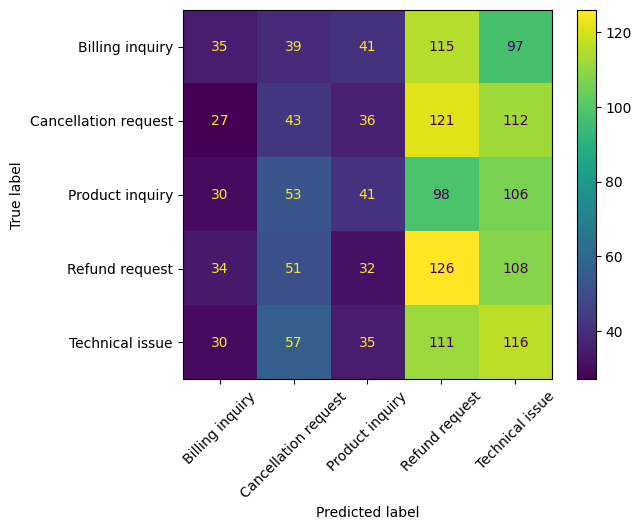

In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(nb_model, X_test_tfidf, y_test, xticks_rotation=45)
plt.show()

**What this means**
```python
The Naive Bayes baseline is weak for this dataset in the current setup.
From the confusion matrix, the model is predicting many tickets as:
Refund request
Technical issue
That means it is not separating the classes well.

**Why this may be happening**
- Reason 1 — Naive Bayes is too simple
>Multinomial Naive Bayes is a useful baseline, but sometimes it is too simple for multiclass support-ticket language.
- Reason 2 — Ticket descriptions may share similar vocabulary
> Customer tickets may use overlapping words like:
-      issue
-      problem
-      help
-      account
-      order
-      support
> So the model cannot separate categories well with this method alone.
- Reason 3 — Ticket Description may not be enough by itself
>Maybe Ticket Subject also contains important signal.

That means later we may improve the model by using:
> Ticket Subject + Ticket Description

instead of only description.

The baseline Multinomial Naive Bayes model produced low performance, with an accuracy of 0.213. Because the task contains five classes, this result is only slightly above random guessing. The confusion matrix shows that the model frequently predicted tickets as “Refund request” or “Technical issue,” indicating weak separation between categories. The classification report also shows low recall for most classes, especially Billing inquiry, Cancellation request, and Product inquiry. This suggests that Naive Bayes with TF-IDF on Ticket Description alone is not sufficient for strong classification on this dataset.

↪ **Compare additional models** :
>Use:
1. Logistic Regression
2. Linear SVM

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

# Logistic Regression
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train)
y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nLogistic Regression Classification Report:\n")
print(classification_report(y_test, y_pred_lr))

# Linear SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nLinear SVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.20188902007083825

Logistic Regression Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.18      0.19       327
Cancellation request       0.19      0.18      0.19       339
     Product inquiry       0.20      0.21      0.21       328
      Refund request       0.22      0.23      0.23       351
     Technical issue       0.20      0.21      0.20       349

            accuracy                           0.20      1694
           macro avg       0.20      0.20      0.20      1694
        weighted avg       0.20      0.20      0.20      1694

Linear SVM Accuracy: 0.2024793388429752

Linear SVM Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.20      0.20       327
Cancellation request       0.19      0.19      0.19       339
     Product inquiry       0.20      0.20      0.20       328
      Refund reques

**What happened**

All three models are around 0.20–0.21:

1. Naive Bayes: 0.213
2. Logistic Regression: 0.202
3. Linear SVM: 0.202

With 5 classes, random chance is about 0.20.

So the project has revealed something very valuable:

The problem is probably not the model

The problem is likely the input signal.

In simple words:

Ticket Description alone may not contain enough information to predict Ticket Type well.

**Best next move**

We don't stop here.

Now do the smartest improvement:

Use:

Ticket Subject + Ticket Description

Instead of only:
Ticket Description

That is the most logical next step.

In [28]:
# Create combined text
df['combined_text'] = df['Ticket Subject'].astype(str) + " " + df['Ticket Description'].astype(str)

In [29]:
# Clean it
df['cleaned_combined_text'] = df['combined_text'].apply(clean_text)

In [30]:
#c Redefine X
X = df['cleaned_combined_text']
y = df['Ticket Type']

In [31]:
# Split again
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [32]:
# TF-IDF again
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [33]:
# Train the strongest model first
# Use Linear SVM:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.19480519480519481

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.19      0.19      0.19       327
Cancellation request       0.16      0.16      0.16       339
     Product inquiry       0.20      0.19      0.19       328
      Refund request       0.22      0.21      0.22       351
     Technical issue       0.20      0.22      0.21       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



 ▶  **Feature engineering with better TF-IDF**

**Step 1 — create combined text**

In [34]:
df['combined_text'] = df['Ticket Subject'].astype(str) + " " + df['Ticket Description'].astype(str)

In [35]:
# Then clean it:
df['cleaned_combined_text'] = df['combined_text'].apply(clean_text)

In [36]:
# Now inspect it:
df[['Ticket Subject', 'Ticket Description', 'cleaned_combined_text']].head()

,Ticket Subject,Ticket Description,cleaned_combined_text
0,Product setup,I'm having an issue with the {product_purchase...,product setup im having an issue with the prod...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,peripheral compatibility im having an issue wi...
2,Network problem,I'm facing a problem with my {product_purchase...,network problem im facing a problem with my pr...
3,Account access,I'm having an issue with the {product_purchase...,account access im having an issue with the pro...
4,Data loss,I'm having an issue with the {product_purchase...,data loss im having an issue with the productp...


**What we have**

Now each row contains:
- subject
- description
- one cleaned combined text field

**Step 2 — define X and y**

In [37]:
X = df['cleaned_combined_text']
y = df['Ticket Type']

**Step 3 — split the data**

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [39]:
# Then check:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(6775,) (1694,) (6775,) (1694,)


**Step 4 — build better TF-IDF with n-grams**

In [40]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

In [41]:
# Now fit and transform:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [42]:
# Check shape:
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape:", X_test_tfidf.shape)

X_train_tfidf shape: (6775, 13852)
X_test_tfidf shape: (1694, 13852)


**Step 5 — train Linear SVM**

In [43]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

LinearSVC()

In [44]:
# Then predict:
y_pred_svm = svm_model.predict(X_test_tfidf)

**Step 6 — evaluate**

In [45]:
from sklearn.metrics import accuracy_score, classification_report

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.19303423848878395

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.18      0.18      0.18       327
Cancellation request       0.18      0.19      0.19       339
     Product inquiry       0.19      0.18      0.18       328
      Refund request       0.20      0.21      0.20       351
     Technical issue       0.22      0.21      0.21       349

            accuracy                           0.19      1694
           macro avg       0.19      0.19      0.19      1694
        weighted avg       0.19      0.19      0.19      1694



**Step 7 — inspect the strongest words/phrases per class**

In [46]:
feature_names = tfidf.get_feature_names_out()

for i, class_label in enumerate(svm_model.classes_):
    top10 = svm_model.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop features for class: {class_label}")
    for idx in top10:
        print(feature_names[idx])


Top features for class: Billing inquiry
no we
connect
core
product please
that im
productkey
later
apps
this error
purchased to

Top features for class: Cancellation request
about my
solution yes
account no
newsletter
admin
your issue
donation
productpurchased product
problem to
is on

Top features for class: Product inquiry
options
ds
account in
productp
has im
id im
please send
if have
same ive
purchased true

Top features for class: Refund request
the right
warning
am having
productpurchasing
brand name
do with
please let
note the
can im
crate

Top features for class: Technical issue
account step
dont make
we wont
thanks this
red
crash
installing
thanks the
dear
productpurchased will


In [47]:
for label in df['Ticket Type'].unique():
    print(f"\n===== {label} =====")
    sample_rows = df[df['Ticket Type'] == label][['Ticket Subject', 'Ticket Description']].sample(5, random_state=42)
    print(sample_rows.to_string(index=False))


===== Technical issue =====
        Ticket Subject                                                                                                                                                                                                                                                                                                                                               Ticket Description
         Product setup                                  I'm having an issue with the {product_purchased}. Please assist. I've added a new product, {id} {product_purchased}, which requires 1 sign-on time and adds an option on the right side to I'm unable to find the option to perform the desired action in the {product_purchased}. Could you please guide me through the steps?
          Software bug                                                                                                                                                                                                I'm h

In [48]:
df[['Ticket Subject', 'Ticket Description', 'Ticket Type']].sample(20, random_state=42).to_string(index=False)

'          Ticket Subject                                                                                                                                                                                                                                                                                                                                             Ticket Description          Ticket Type\n           Product setup                                                           I\'m having an issue with the {product_purchased}. Please assist. I\'m using xda-developer for something different. If there are issues with the {product_purchased} it\'s likely you are not using the I\'ve tried clearing the cache and data for the {product_purchased} app, but the issue persists.       Refund request\n            Battery life                                  I\'m having trouble connecting my {product_purchased} to my home Wi-Fi network. It doesn\'t detect any networks, although other devices are c

In [49]:
df['combined_raw'] = df['Ticket Subject'].astype(str) + " " + df['Ticket Description'].astype(str)

duplicate_texts = df.groupby('combined_raw')['Ticket Type'].nunique()
conflicting_duplicates = duplicate_texts[duplicate_texts > 1]

print("Number of text entries assigned to more than one Ticket Type:", len(conflicting_duplicates))

Number of text entries assigned to more than one Ticket Type: 85


In [50]:
from collections import Counter

for label in df['Ticket Type'].unique():
    text = " ".join(df[df['Ticket Type'] == label]['cleaned_combined_text'])
    words = text.split()
    common_words = Counter(words).most_common(20)
    print(f"\n===== {label} =====")
    print(common_words)


===== Technical issue =====
[('the', 5484), ('productpurchased', 2886), ('issue', 2704), ('to', 2172), ('im', 2131), ('my', 1932), ('please', 1838), ('with', 1706), ('it', 1550), ('an', 1525), ('a', 1408), ('having', 1346), ('assist', 1303), ('and', 1245), ('ive', 1219), ('i', 1195), ('is', 1168), ('you', 957), ('this', 905), ('but', 903)]

===== Billing inquiry =====
[('the', 5044), ('productpurchased', 2701), ('issue', 2472), ('to', 2129), ('im', 1986), ('my', 1887), ('please', 1690), ('with', 1625), ('it', 1434), ('an', 1405), ('a', 1346), ('having', 1239), ('i', 1211), ('assist', 1208), ('ive', 1150), ('and', 1136), ('is', 1113), ('this', 835), ('you', 831), ('but', 819)]

===== Cancellation request =====
[('the', 5226), ('productpurchased', 2814), ('issue', 2635), ('to', 2102), ('im', 2064), ('my', 1888), ('please', 1763), ('with', 1663), ('it', 1502), ('an', 1449), ('a', 1372), ('having', 1287), ('assist', 1254), ('ive', 1196), ('and', 1186), ('i', 1152), ('is', 1133), ('but', 9

**Step 1 — add stronger cleaning**

In [60]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_noise_words = {
    'im', 'ive', 'id', 'please', 'assist', 'issue', 'issues',
    'productpurchased', 'having', 'would', 'could', 'also',
    'get', 'got', 'us', 'hi', 'hello', 'thanks', 'thank'
}

all_stopwords = set(ENGLISH_STOP_WORDS).union(custom_noise_words)

def clean_text_stronger(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in all_stopwords and len(word) > 2]

    return " ".join(words)

**Step 2 — apply it to combined text**

In [61]:
df['combined_text'] = df['Ticket Subject'].astype(str) + " " + df['Ticket Description'].astype(str)
df['cleaned_combined_text_v2'] = df['combined_text'].apply(clean_text_stronger)

In [62]:
# Check it:
df[['combined_text', 'cleaned_combined_text_v2']].head(5)

,combined_text,cleaned_combined_text_v2
0,Product setup I'm having an issue with the {pr...,product setup billing zip code appreciate requ...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility need change existing ...
2,Network problem I'm facing a problem with my {...,network problem facing problem turning working...
3,Account access I'm having an issue with the {p...,account access problem interested love happen ...
4,Data loss I'm having an issue with the {produc...,data loss note seller responsible damages aris...


**Step 3 — redefine X and y**

In [63]:
X = df['cleaned_combined_text_v2']
y = df['Ticket Type']

**Step 4 — split again**

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

**Step 5 — TF-IDF with n-grams again**

In [65]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

In [66]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**Step 6 — train Linear SVM again**

In [67]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.22077922077922077

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.24      0.25      0.25       327
Cancellation request       0.21      0.22      0.22       339
     Product inquiry       0.22      0.22      0.22       328
      Refund request       0.21      0.20      0.20       351
     Technical issue       0.22      0.22      0.22       349

            accuracy                           0.22      1694
           macro avg       0.22      0.22      0.22      1694
        weighted avg       0.22      0.22      0.22      1694



**Step 7 — inspect top features again**

In [68]:
feature_names = tfidf.get_feature_names_out()

for i, class_label in enumerate(svm_model.classes_):
    top10 = svm_model.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop features for class: {class_label}")
    for idx in top10:
        print(feature_names[idx])


Top features for class: Billing inquiry
connect
buy item
time performed
apps
address facing
try best
copyright
access using
hardware return
life using

Top features for class: Cancellation request
donation
available don
solution yes
newsletter
try try
compatibility concerned
solution sorry
admin
resolve facing
machines

Top features for class: Product inquiry
information product
request item
request result
rob
immediate
shortly
options
turned
know noticed
getting email

Top features for class: Refund request
contact followed
access working
reinstall
display noticed
note facing
warning
loss item
payment contacted
information facing
payment making

Top features for class: Technical issue
available time
crash
feeling
don make
solution product
device screen
history
account step
case checked
request followed


**Next experiment**

In [69]:
df['cleaned_subject'] = df['Ticket Subject'].apply(clean_text_stronger)

In [70]:
X = df['cleaned_subject']
y = df['Ticket Type']

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [72]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.90,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [73]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)

print("Linear SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

Linear SVM Accuracy: 0.1782762691853601

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.09      0.12       327
Cancellation request       0.20      0.18      0.19       339
     Product inquiry       0.21      0.14      0.17       328
      Refund request       0.19      0.23      0.21       351
     Technical issue       0.16      0.25      0.19       349

            accuracy                           0.18      1694
           macro avg       0.18      0.18      0.17      1694
        weighted avg       0.18      0.18      0.17      1694



In [74]:
feature_names = tfidf.get_feature_names_out()

for i, class_label in enumerate(svm_model.classes_):
    top10 = svm_model.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop features for class: {class_label}")
    for idx in top10:
        print(feature_names[idx])


Top features for class: Billing inquiry
product compatibility
payment
delivery
delivery problem
account
account access
access
compatibility
installation support
support

Top features for class: Cancellation request
refund request
refund
request
cancellation
cancellation request
data loss
data
loss
display
payment

Top features for class: Product inquiry
product compatibility
recommendation
product recommendation
product
network
network problem
software bug
software
bug
refund

Top features for class: Refund request
hardware
battery
battery life
life
peripheral
peripheral compatibility
support
installation
installation support
cancellation

Top features for class: Technical issue
network
network problem
product setup
setup
cancellation
cancellation request
problem
peripheral compatibility
peripheral
installation support


In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score

X = df['cleaned_combined_text_v2']
y = df['Ticket Type']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

results = []

for ngram in [(1,1), (1,2), (1,3)]:
    for min_df in [2, 3, 5]:
        for max_df in [0.85, 0.90, 0.95]:
            for C in [0.5, 1.0, 2.0]:
                tfidf = TfidfVectorizer(
                    ngram_range=ngram,
                    min_df=min_df,
                    max_df=max_df,
                    sublinear_tf=True
                )

                X_train_tfidf = tfidf.fit_transform(X_train)
                X_test_tfidf = tfidf.transform(X_test)

                model = LinearSVC(C=C)
                model.fit(X_train_tfidf, y_train)
                y_pred = model.predict(X_test_tfidf)

                acc = accuracy_score(y_test, y_pred)

                results.append({
                    'ngram': ngram,
                    'min_df': min_df,
                    'max_df': max_df,
                    'C': C,
                    'accuracy': acc
                })

results = sorted(results, key=lambda x: x['accuracy'], reverse=True)

for r in results[:10]:
    print(r)

{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.85, 'C': 2.0, 'accuracy': 0.22727272727272727}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.9, 'C': 2.0, 'accuracy': 0.22727272727272727}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.95, 'C': 2.0, 'accuracy': 0.22727272727272727}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.85, 'C': 1.0, 'accuracy': 0.22668240850059032}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.9, 'C': 1.0, 'accuracy': 0.22668240850059032}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.95, 'C': 1.0, 'accuracy': 0.22668240850059032}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.85, 'C': 0.5, 'accuracy': 0.2255017709563164}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.9, 'C': 0.5, 'accuracy': 0.2255017709563164}
{'ngram': (1, 3), 'min_df': 2, 'max_df': 0.95, 'C': 0.5, 'accuracy': 0.2255017709563164}
{'ngram': (1, 2), 'min_df': 3, 'max_df': 0.85, 'C': 0.5, 'accuracy': 0.22195985832349469}


NEW

In [76]:
import re
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

custom_noise_words = {
    'im', 'ive', 'id', 'please', 'assist', 'issue', 'issues',
    'productpurchased', 'having', 'would', 'could', 'also',
    'get', 'got', 'us', 'hi', 'hello', 'thanks', 'thank',
    'history', 'feeling', 'warning', 'connect', 'copyright', 'machines'
}

noise_phrases = [
    'account step',
    'case checked',
    'request followed',
    'available time',
    'contact followed',
    'getting email',
    'know noticed',
    'solution sorry',
    'try try',
    'life using',
    'try best',
    'address facing'
]

all_stopwords = set(ENGLISH_STOP_WORDS).union(custom_noise_words)

def clean_text_stronger_v3(text):
    text = text.lower()
    text = re.sub(r'\{.*?\}', ' ', text)

    # remove exact noisy phrases first
    for phrase in noise_phrases:
        text = text.replace(phrase, ' ')

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()
    words = [word for word in words if word not in all_stopwords and len(word) > 2]

    return " ".join(words)

In [77]:
df['cleaned_combined_text_v3'] = df['combined_text'].apply(clean_text_stronger_v3)

In [78]:
df[['combined_text', 'cleaned_combined_text_v3']].head(5)

,combined_text,cleaned_combined_text_v3
0,Product setup I'm having an issue with the {pr...,product setup billing zip code appreciate requ...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility need change existing ...
2,Network problem I'm facing a problem with my {...,network problem facing problem turning working...
3,Account access I'm having an issue with the {p...,account access problem interested love happen ...
4,Data loss I'm having an issue with the {produc...,data loss note seller responsible damages aris...


In [79]:
X = df['cleaned_combined_text_v3']
y = df['Ticket Type']

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 3),
    min_df=2,
    max_df=0.85,
    sublinear_tf=True
)

In [82]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [83]:
from sklearn.svm import LinearSVC

best_model = LinearSVC(C=2.0)
best_model.fit(X_train_tfidf, y_train)

LinearSVC(C=2.0)

In [84]:
y_pred_best = best_model.predict(X_test_tfidf)

In [85]:
from sklearn.metrics import accuracy_score, classification_report

print("Best Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_best))

Best Accuracy: 0.22668240850059032

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.25      0.26      0.26       327
Cancellation request       0.22      0.22      0.22       339
     Product inquiry       0.21      0.22      0.22       328
      Refund request       0.23      0.22      0.22       351
     Technical issue       0.22      0.21      0.22       349

            accuracy                           0.23      1694
           macro avg       0.23      0.23      0.23      1694
        weighted avg       0.23      0.23      0.23      1694



In [86]:
feature_names = tfidf.get_feature_names_out()

for i, class_label in enumerate(best_model.classes_):
    top10 = best_model.coef_[i].argsort()[-10:][::-1]
    print(f"\nTop features for class: {class_label}")
    for idx in top10:
        print(feature_names[idx])


Top features for class: Billing inquiry
buy item
try best
hardware return
hardware doing
later
database
week try
truth
payment tried using
product able

Top features for class: Cancellation request
donation
refund request need
try try
admin
newsletter
requested file
recommendation tried different
connection
product received
prices shown

Top features for class: Product inquiry
information product
immediate
rob
hardware noticed occurs
located
sees
shortly
lazy
turned
delivery problem contacted

Top features for class: Refund request
reinstall
compatibility tried different
involved
contact followed
layout
won work
try add
contact retailer
note facing
note facing intermittent

Top features for class: Technical issue
available time
crash
don make
device screen
access checked software
solution product
help tried troubleshooting
display problem started
payment say
installing


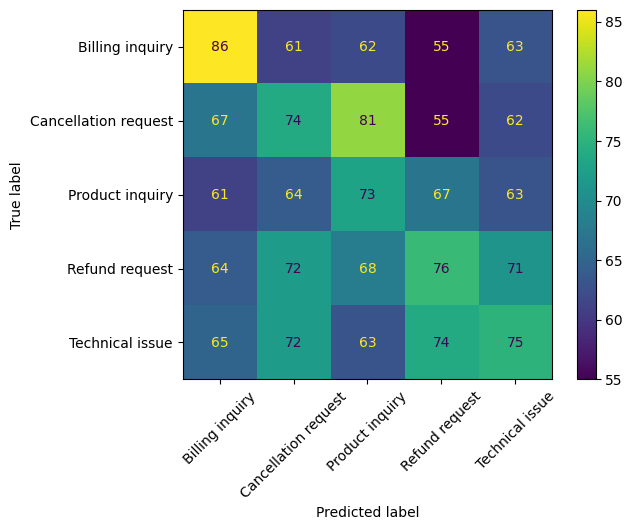

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(best_model, X_test_tfidf, y_test, xticks_rotation=45)
plt.show()

**Conclusion**

This project aimed to classify customer support tickets into five categories using NLP and machine learning. Several text-based approaches were tested, including TF-IDF vectorization, Multinomial Naive Bayes, Logistic Regression, and Linear SVM. Additional rescue steps were also applied, such as combining ticket subject and description, removing repeated generic support language, using n-grams, and tuning vectorizer and model settings.

Although these steps produced small improvements, the final performance remained weak, with the best accuracy reaching only about 0.23. The investigation showed that the main limitation was not simply model choice, but the quality and structure of the dataset itself. The text fields contained repeated template language, noisy phrases, weak alignment between ticket text and ticket type, and conflicting patterns across labels. As a result, the dataset did not provide a strong and stable signal for learning the target classes.

This project was still valuable because it demonstrated an important real-world machine learning lesson: model performance depends heavily on data quality, label consistency, and alignment between input features and the prediction target. In other words, when the data-generating process is weak or inconsistent, even reasonable models and feature engineering efforts will have limited success. The final outcome of this project is therefore both a classification attempt and a diagnostic case study showing the principle of garbage in, garbage out.